In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import accuracy_score, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
MODEL_PATH = r"E:\DermaAI_DiagnosticTool\models\mobilenetv2_finetuned_final_model.keras"
SPLIT_DIR = r"E:\DermaAI_DiagnosticTool\outputs\splits"
OUTPUT_DIR = r"E:\DermaAI_DiagnosticTool\outputs"
CALIBRATION_DIR = os.path.join(OUTPUT_DIR, "calibration_outputs")

os.makedirs(CALIBRATION_DIR, exist_ok=True)

model = load_model(MODEL_PATH)

test_df = pd.read_csv(os.path.join(SPLIT_DIR, "test_metadata.csv"))

CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

lesion_type_dict = {
    "akiec": "Actinic keratoses and intraepithelial carcinoma",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions"
}

class_to_index = {class_name: index for index, class_name in enumerate(CLASS_NAMES)}
index_to_class = {index: class_name for index, class_name in enumerate(CLASS_NAMES)}

print("Model loaded successfully")
print("Test shape:", test_df.shape)
print("Calibration output folder:", CALIBRATION_DIR)

print("\nSample path exists:")
print(os.path.exists(test_df["image_path"].iloc[0]))

Model loaded successfully
Test shape: (1549, 10)
Calibration output folder: E:\DermaAI_DiagnosticTool\outputs\calibration_outputs

Sample path exists:
True


In [3]:
IMG_SIZE = (224, 224)

def load_single_image(image_path):
    img = image.load_img(image_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

In [4]:
def predict_single_image(image_path):
    img_array = load_single_image(image_path)

    probabilities = model.predict(img_array, verbose=0)[0]

    predicted_index = int(np.argmax(probabilities))
    predicted_label = CLASS_NAMES[predicted_index]
    confidence = float(probabilities[predicted_index])

    probability_table = pd.DataFrame({
        "class_code": CLASS_NAMES,
        "class_name": [lesion_type_dict[class_code] for class_code in CLASS_NAMES],
        "probability": probabilities
    })

    probability_table["probability_percent"] = (
        probability_table["probability"] * 100
    ).round(2)

    probability_table = probability_table.sort_values(
        by="probability",
        ascending=False
    ).reset_index(drop=True)

    top_3 = probability_table.head(3)

    return {
        "predicted_label": predicted_label,
        "predicted_class_name": lesion_type_dict[predicted_label],
        "confidence": confidence,
        "confidence_percent": round(confidence * 100, 2),
        "probabilities": probabilities,
        "probability_table": probability_table,
        "top_3": top_3
    }

In [5]:
def generate_decision_support_flags(probability_table):
    top_1 = probability_table.iloc[0]
    top_2 = probability_table.iloc[1]

    predicted_label = top_1["class_code"]
    confidence = float(top_1["probability"])
    second_confidence = float(top_2["probability"])
    margin = confidence - second_confidence

    flags = []

    if confidence < 0.50:
        flags.append(
            "Low confidence prediction. Clinical review is strongly recommended."
        )

    if margin < 0.15:
        flags.append(
            "Uncertainty detected between the top two predicted classes."
        )

    if predicted_label in ["mel", "bcc", "akiec"]:
        flags.append(
            "Potentially higher risk class predicted. Urgent clinical review is recommended."
        )

    if len(flags) == 0:
        flags.append(
            "Prediction confidence is acceptable, but clinical review is still required."
        )

    return {
        "predicted_label": predicted_label,
        "confidence_percent": round(confidence * 100, 2),
        "second_label": top_2["class_code"],
        "second_confidence_percent": round(second_confidence * 100, 2),
        "margin_percent": round(margin * 100, 2),
        "flags": flags
    }

In [6]:
sample_row = test_df.sample(1, random_state=12).iloc[0]
sample_path = sample_row["image_path"]
true_label = sample_row["dx"]

single_result = predict_single_image(sample_path)
support_flags = generate_decision_support_flags(single_result["probability_table"])

print("True label:", true_label, "-", lesion_type_dict[true_label])
print("Predicted label:", single_result["predicted_label"], "-", single_result["predicted_class_name"])
print("Confidence:", single_result["confidence_percent"], "%")

print("\nTop 3 predictions:")
display(single_result["top_3"])

print("\nDecision support flags:")
for flag in support_flags["flags"]:
    print("-", flag)

True label: nv - Melanocytic nevi
Predicted label: mel - Melanoma
Confidence: 39.04 %

Top 3 predictions:


,class_code,class_name,probability,probability_percent
0,mel,Melanoma,0.390409,39.040001
1,nv,Melanocytic nevi,0.251605,25.160000
2,bkl,Benign keratosis like lesions,0.217764,21.780001



Decision support flags:
- Low confidence prediction. Clinical review is strongly recommended.
- Uncertainty detected between the top two predicted classes.
- Potentially higher risk class predicted. Urgent clinical review is recommended.


In [7]:
tta_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)

def predict_with_tta(image_path, n_augments=8):
    img = image.load_img(image_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    batch = np.expand_dims(img_array, axis=0)

    predictions = []

    original_prediction = model.predict(
        preprocess_input(batch.copy()),
        verbose=0
    )[0]

    predictions.append(original_prediction)

    generator = tta_datagen.flow(
        batch,
        batch_size=1,
        shuffle=False
    )

    for _ in range(n_augments):
        augmented_image = next(generator)
        prediction = model.predict(augmented_image, verbose=0)[0]
        predictions.append(prediction)

    mean_probabilities = np.mean(predictions, axis=0)

    predicted_index = int(np.argmax(mean_probabilities))
    predicted_label = CLASS_NAMES[predicted_index]
    confidence = float(mean_probabilities[predicted_index])

    probability_table = pd.DataFrame({
        "class_code": CLASS_NAMES,
        "class_name": [lesion_type_dict[class_code] for class_code in CLASS_NAMES],
        "probability": mean_probabilities
    })

    probability_table["probability_percent"] = (
        probability_table["probability"] * 100
    ).round(2)

    probability_table = probability_table.sort_values(
        by="probability",
        ascending=False
    ).reset_index(drop=True)

    return {
        "predicted_label": predicted_label,
        "predicted_class_name": lesion_type_dict[predicted_label],
        "confidence": confidence,
        "confidence_percent": round(confidence * 100, 2),
        "probabilities": mean_probabilities,
        "probability_table": probability_table,
        "top_3": probability_table.head(3)
    }

In [8]:
tta_result = predict_with_tta(sample_path, n_augments=8)
tta_flags = generate_decision_support_flags(tta_result["probability_table"])

print("True label:", true_label, "-", lesion_type_dict[true_label])

print("\nNormal prediction:")
print(single_result["predicted_label"], "-", single_result["confidence_percent"], "%")
display(single_result["top_3"])

print("\nTTA prediction:")
print(tta_result["predicted_label"], "-", tta_result["confidence_percent"], "%")
display(tta_result["top_3"])

print("\nTTA decision support flags:")
for flag in tta_flags["flags"]:
    print("-", flag)

True label: nv - Melanocytic nevi

Normal prediction:
mel - 39.04 %


,class_code,class_name,probability,probability_percent
0,mel,Melanoma,0.390409,39.040001
1,nv,Melanocytic nevi,0.251605,25.160000
2,bkl,Benign keratosis like lesions,0.217764,21.780001



TTA prediction:
mel - 31.8 %


,class_code,class_name,probability,probability_percent
0,mel,Melanoma,0.317977,31.799999
1,nv,Melanocytic nevi,0.310070,31.010000
2,bkl,Benign keratosis like lesions,0.177103,17.709999



TTA decision support flags:
- Low confidence prediction. Clinical review is strongly recommended.
- Uncertainty detected between the top two predicted classes.
- Potentially higher risk class predicted. Urgent clinical review is recommended.


In [9]:
test_probabilities = []
test_true_labels = []

for index, row in test_df.iterrows():
    img_array = load_single_image(row["image_path"])
    probabilities = model.predict(img_array, verbose=0)[0]

    test_probabilities.append(probabilities)
    test_true_labels.append(row["dx"])

    if (index + 1) % 100 == 0:
        print("Processed:", index + 1, "images")

test_probabilities = np.array(test_probabilities)
test_true_indices = np.array([class_to_index[label] for label in test_true_labels])
test_pred_indices = np.argmax(test_probabilities, axis=1)
test_confidences = np.max(test_probabilities, axis=1)

normal_accuracy = accuracy_score(test_true_indices, test_pred_indices)

print("Normal test accuracy:", round(normal_accuracy * 100, 2), "%")
print("Mean prediction confidence:", round(np.mean(test_confidences) * 100, 2), "%")

Processed: 100 images
Processed: 200 images
Processed: 300 images
Processed: 400 images
Processed: 500 images
Processed: 600 images
Processed: 700 images
Processed: 800 images
Processed: 900 images
Processed: 1000 images
Processed: 1100 images
Processed: 1200 images
Processed: 1300 images
Processed: 1400 images
Processed: 1500 images
Normal test accuracy: 64.23 %
Mean prediction confidence: 56.6 %


In [10]:
def calculate_ece(confidences, predictions, true_labels, n_bins=10):
    bin_boundaries = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    calibration_rows = []

    for bin_index in range(n_bins):
        bin_lower = bin_boundaries[bin_index]
        bin_upper = bin_boundaries[bin_index + 1]

        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        proportion_in_bin = np.mean(in_bin)

        if proportion_in_bin > 0:
            accuracy_in_bin = np.mean(predictions[in_bin] == true_labels[in_bin])
            avg_confidence_in_bin = np.mean(confidences[in_bin])
            count_in_bin = np.sum(in_bin)

            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * proportion_in_bin

            calibration_rows.append({
                "bin_lower": bin_lower,
                "bin_upper": bin_upper,
                "count": count_in_bin,
                "accuracy": accuracy_in_bin,
                "average_confidence": avg_confidence_in_bin,
                "gap": abs(avg_confidence_in_bin - accuracy_in_bin)
            })

    return ece, pd.DataFrame(calibration_rows)

ece_score, calibration_df = calculate_ece(
    test_confidences,
    test_pred_indices,
    test_true_indices,
    n_bins=10
)

print("Expected Calibration Error:", round(ece_score, 4))

display(calibration_df)

calibration_csv_path = os.path.join(
    CALIBRATION_DIR,
    "normal_prediction_calibration_bins.csv"
)

calibration_df.to_csv(calibration_csv_path, index=False)

print("Calibration data saved to:", calibration_csv_path)

Expected Calibration Error: 0.0818


,bin_lower,bin_upper,count,accuracy,average_confidence,gap
0,0.1,0.2,1,1.000000,0.192833,0.807167
1,0.2,0.3,129,0.395349,0.267169,0.128180
2,0.3,0.4,287,0.337979,0.352510,0.014531
3,0.4,0.5,306,0.493464,0.449209,0.044255
4,0.5,0.6,205,0.712195,0.549046,0.163149
5,0.6,0.7,178,0.803371,0.648026,0.155345
6,0.7,0.8,150,0.820000,0.752480,0.067520
7,0.8,0.9,143,0.958042,0.847211,0.110831
8,0.9,1.0,150,0.973333,0.943294,0.030039


Calibration data saved to: E:\DermaAI_DiagnosticTool\outputs\calibration_outputs\normal_prediction_calibration_bins.csv


## Normal Prediction Calibration Result

The fine tuned MobileNetV2 model achieved a normal test accuracy of 64.23 percent with a mean prediction confidence of 56.60 percent. This shows that the model is not excessively overconfident overall, which is important for a medical decision support context.

The Expected Calibration Error was 0.0818. This indicates that there is still a measurable gap between predicted confidence and actual accuracy, but the confidence behaviour is reasonable for a proof of concept system. The reliability analysis supports the need to present confidence scores, top 3 probabilities and uncertainty warnings rather than showing only a single predicted diagnosis.

For the sample image, Test Time Augmentation reduced the top confidence from 39.04 percent to 31.80 percent and made the top two classes very close. This did not correct the prediction, but it made the model uncertainty more visible. This supports the use of uncertainty flags in the final web application.

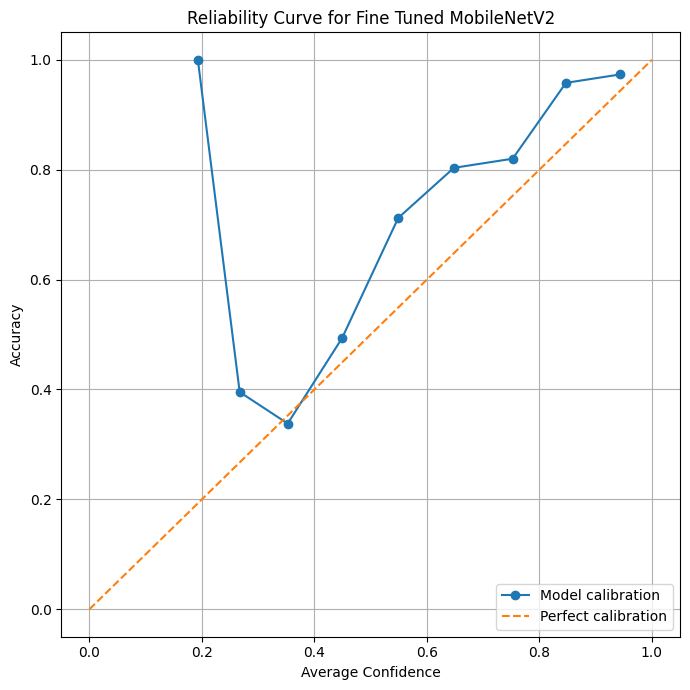

Reliability curve saved to: E:\DermaAI_DiagnosticTool\outputs\calibration_outputs\reliability_curve_finetuned_mobilenetv2.png


In [11]:
plt.figure(figsize=(7, 7))

plt.plot(
    calibration_df["average_confidence"],
    calibration_df["accuracy"],
    marker="o",
    label="Model calibration"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.title("Reliability Curve for Fine Tuned MobileNetV2")
plt.xlabel("Average Confidence")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

reliability_plot_path = os.path.join(
    CALIBRATION_DIR,
    "reliability_curve_finetuned_mobilenetv2.png"
)

plt.savefig(reliability_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Reliability curve saved to:", reliability_plot_path)

In [12]:
TTA_SAMPLE_SIZE = 50
TTA_AUGMENTS = 5

tta_sample_df = test_df.sample(TTA_SAMPLE_SIZE, random_state=42)

tta_predictions = []
tta_true_labels = []
tta_confidences = []
tta_probability_rows = []

for count, (_, row) in enumerate(tta_sample_df.iterrows(), start=1):
    result = predict_with_tta(row["image_path"], n_augments=TTA_AUGMENTS)

    tta_predictions.append(result["predicted_label"])
    tta_true_labels.append(row["dx"])
    tta_confidences.append(result["confidence"])

    tta_probability_rows.append({
        "image_id": row["image_id"],
        "true_label": row["dx"],
        "predicted_label": result["predicted_label"],
        "confidence_percent": result["confidence_percent"]
    })

    if count % 10 == 0:
        print("Processed TTA images:", count)

tta_true_indices = np.array([class_to_index[label] for label in tta_true_labels])
tta_pred_indices = np.array([class_to_index[label] for label in tta_predictions])
tta_confidences = np.array(tta_confidences)

tta_accuracy = accuracy_score(tta_true_indices, tta_pred_indices)

print("TTA sample accuracy:", round(tta_accuracy * 100, 2), "%")
print("TTA mean confidence:", round(np.mean(tta_confidences) * 100, 2), "%")

tta_results_df = pd.DataFrame(tta_probability_rows)

display(tta_results_df.head())

tta_results_path = os.path.join(
    CALIBRATION_DIR,
    "tta_sample_prediction_results.csv"
)

tta_results_df.to_csv(tta_results_path, index=False)

print("TTA results saved to:", tta_results_path)

Processed TTA images: 10
Processed TTA images: 20
Processed TTA images: 30
Processed TTA images: 40
Processed TTA images: 50
TTA sample accuracy: 62.0 %
TTA mean confidence: 56.25 %


,image_id,true_label,predicted_label,confidence_percent
0,ISIC_0031931,mel,akiec,43.36
1,ISIC_0030578,nv,df,42.50
2,ISIC_0033398,nv,df,42.94
3,ISIC_0032797,mel,mel,33.55
4,ISIC_0028958,bkl,nv,41.35


TTA results saved to: E:\DermaAI_DiagnosticTool\outputs\calibration_outputs\tta_sample_prediction_results.csv


In [13]:
summary_data = {
    "Stage": [
        "Fine Tuned MobileNetV2",
        "Normal Prediction Calibration",
        "TTA Sample Evaluation"
    ],
    "Purpose": [
        "Final selected classification model",
        "Assess whether confidence scores are reliable",
        "Assess whether averaged augmented predictions improve stability"
    ],
    "Accuracy": [
        0.6423,
        normal_accuracy,
        tta_accuracy
    ],
    "Mean Confidence": [
        None,
        float(np.mean(test_confidences)),
        float(np.mean(tta_confidences))
    ],
    "Notes": [
        "Best current saved model from fine tuning stage",
        f"ECE score: {round(ece_score, 4)}",
        f"Sample size: {TTA_SAMPLE_SIZE}, augmentations per image: {TTA_AUGMENTS}"
    ]
}

improvement_summary_df = pd.DataFrame(summary_data)

display(improvement_summary_df)

summary_path = os.path.join(
    CALIBRATION_DIR,
    "model_improvement_and_calibration_summary.csv"
)

improvement_summary_df.to_csv(summary_path, index=False)

print("Improvement summary saved to:", summary_path)

,Stage,Purpose,Accuracy,Mean Confidence,Notes
0,Fine Tuned MobileNetV2,Final selected classification model,0.64230,NaN,Best current saved model from fine tuning stage
1,Normal Prediction Calibration,Assess whether confidence scores are reliable,0.64235,0.565982,ECE score: 0.0818
2,TTA Sample Evaluation,Assess whether averaged augmented predictions ...,0.62000,0.562485,"Sample size: 50, augmentations per image: 5"


Improvement summary saved to: E:\DermaAI_DiagnosticTool\outputs\calibration_outputs\model_improvement_and_calibration_summary.csv


## Model Improvement and Calibration Summary

This notebook explored methods for improving the reliability of the fine tuned MobileNetV2 diagnostic support model. The aim was not only to increase prediction confidence, but to make the confidence output more clinically responsible and easier to interpret.

The model achieved a normal test accuracy of 64.23 percent with a mean prediction confidence of 56.60 percent. The Expected Calibration Error was 0.0818, showing that the model has a measurable but manageable gap between confidence and actual correctness.

Test Time Augmentation was implemented to average predictions across multiple augmented versions of the same input image. In the tested sample, TTA reduced the top prediction confidence and made the uncertainty between melanoma and melanocytic nevi more visible. This supports the use of top 3 probability outputs and uncertainty warnings in the final system.

A decision support rule system was also created to flag low confidence predictions, small probability margins between the top two classes and potentially higher risk predictions such as melanoma, basal cell carcinoma and actinic keratoses. These rules align with the project goal of supporting clinical review rather than replacing professional diagnosis.

The calibration analysis, reliability curve, TTA output and decision support flags provide evidence that the system considers uncertainty, reliability and safe deployment concerns.

In [14]:
normal_sample_predictions = []
normal_sample_true_labels = []
normal_sample_confidences = []

for count, (_, row) in enumerate(tta_sample_df.iterrows(), start=1):
    result = predict_single_image(row["image_path"])

    normal_sample_predictions.append(result["predicted_label"])
    normal_sample_true_labels.append(row["dx"])
    normal_sample_confidences.append(result["confidence"])

    if count % 10 == 0:
        print("Processed normal sample images:", count)

normal_sample_true_indices = np.array([
    class_to_index[label] for label in normal_sample_true_labels
])

normal_sample_pred_indices = np.array([
    class_to_index[label] for label in normal_sample_predictions
])

normal_sample_confidences = np.array(normal_sample_confidences)

normal_sample_accuracy = accuracy_score(
    normal_sample_true_indices,
    normal_sample_pred_indices
)

print("Normal sample accuracy:", round(normal_sample_accuracy * 100, 2), "%")
print("Normal sample mean confidence:", round(np.mean(normal_sample_confidences) * 100, 2), "%")

print("TTA sample accuracy:", round(tta_accuracy * 100, 2), "%")
print("TTA sample mean confidence:", round(np.mean(tta_confidences) * 100, 2), "%")

Processed normal sample images: 10
Processed normal sample images: 20
Processed normal sample images: 30
Processed normal sample images: 40
Processed normal sample images: 50
Normal sample accuracy: 70.0 %
Normal sample mean confidence: 58.3 %
TTA sample accuracy: 62.0 %
TTA sample mean confidence: 56.25 %


In [15]:
tta_comparison_df = pd.DataFrame({
    "Method": [
        "Normal prediction on same 50 image sample",
        "TTA prediction on same 50 image sample"
    ],
    "Accuracy": [
        normal_sample_accuracy,
        tta_accuracy
    ],
    "Mean Confidence": [
        float(np.mean(normal_sample_confidences)),
        float(np.mean(tta_confidences))
    ],
    "Sample Size": [
        TTA_SAMPLE_SIZE,
        TTA_SAMPLE_SIZE
    ],
    "Notes": [
        "Single forward pass per image",
        f"Averaged prediction using {TTA_AUGMENTS} augmented versions per image"
    ]
})

display(tta_comparison_df)

tta_comparison_path = os.path.join(
    CALIBRATION_DIR,
    "normal_vs_tta_same_sample_comparison.csv"
)

tta_comparison_df.to_csv(tta_comparison_path, index=False)

print("Normal vs TTA comparison saved to:", tta_comparison_path)

,Method,Accuracy,Mean Confidence,Sample Size,Notes
0,Normal prediction on same 50 image sample,0.70,0.583018,50,Single forward pass per image
1,TTA prediction on same 50 image sample,0.62,0.562485,50,Averaged prediction using 5 augmented versions...


Normal vs TTA comparison saved to: E:\DermaAI_DiagnosticTool\outputs\calibration_outputs\normal_vs_tta_same_sample_comparison.csv


## Normal Prediction and TTA Comparison

A fair comparison was conducted by evaluating both normal prediction and Test Time Augmentation on the same 50 image sample. This avoids comparing the full test set result against a smaller TTA sample.

The purpose of this comparison was to determine whether TTA should be used as the default prediction method in the final application. If TTA improves accuracy or produces more stable probabilities on the same sample, it can be considered for default use. If not, the standard model prediction should remain the main output, while TTA can still be used as an optional uncertainty analysis method.

The earlier single image example showed that TTA reduced the top confidence and made uncertainty between melanoma and melanocytic nevi more visible. This supports the use of TTA as a stability checking method, even if it does not significantly improve classification accuracy.

In [16]:
summary_data = {
    "Stage": [
        "Fine Tuned MobileNetV2",
        "Normal Prediction Calibration",
        "Normal Same Sample Evaluation",
        "TTA Same Sample Evaluation"
    ],
    "Purpose": [
        "Final selected classification model",
        "Assess whether confidence scores are reliable",
        "Evaluate normal prediction on the same sample used for TTA",
        "Assess whether averaged augmented predictions improve stability"
    ],
    "Accuracy": [
        0.6423,
        normal_accuracy,
        normal_sample_accuracy,
        tta_accuracy
    ],
    "Mean Confidence": [
        None,
        float(np.mean(test_confidences)),
        float(np.mean(normal_sample_confidences)),
        float(np.mean(tta_confidences))
    ],
    "Notes": [
        "Best current saved model from fine tuning stage",
        f"ECE score: {round(ece_score, 4)}",
        f"Sample size: {TTA_SAMPLE_SIZE}",
        f"Sample size: {TTA_SAMPLE_SIZE}, augmentations per image: {TTA_AUGMENTS}"
    ]
}

improvement_summary_df = pd.DataFrame(summary_data)

display(improvement_summary_df)

summary_path = os.path.join(
    CALIBRATION_DIR,
    "model_improvement_and_calibration_summary.csv"
)

improvement_summary_df.to_csv(summary_path, index=False)

print("Improvement summary saved to:", summary_path)

,Stage,Purpose,Accuracy,Mean Confidence,Notes
0,Fine Tuned MobileNetV2,Final selected classification model,0.64230,NaN,Best current saved model from fine tuning stage
1,Normal Prediction Calibration,Assess whether confidence scores are reliable,0.64235,0.565982,ECE score: 0.0818
2,Normal Same Sample Evaluation,Evaluate normal prediction on the same sample ...,0.70000,0.583018,Sample size: 50
3,TTA Same Sample Evaluation,Assess whether averaged augmented predictions ...,0.62000,0.562485,"Sample size: 50, augmentations per image: 5"


Improvement summary saved to: E:\DermaAI_DiagnosticTool\outputs\calibration_outputs\model_improvement_and_calibration_summary.csv


## Final Model Improvement Decision

A fair same sample comparison was performed between normal prediction and Test Time Augmentation using the same 50 test images. Normal prediction achieved 70.00 percent accuracy on this sample, while Test Time Augmentation achieved 62.00 percent accuracy.

Since TTA did not improve accuracy on the same sample, the final application will use the standard single prediction method as the default inference approach. TTA will not be used as the main prediction pipeline. However, the TTA experiment remains useful because it showed how augmented prediction averaging can reveal uncertainty in visually similar lesion cases.

The final system will therefore prioritise normal prediction, top 3 probability display, confidence thresholding, uncertainty flags, high risk class warnings and Grad CAM visual explanation. This provides a safer and more clinically responsible workflow than simply increasing prediction confidence artificially.

In [ ]:
report_summary_df = improvement_summary_df.copy()

report_summary_df["Accuracy (%)"] = (
    report_summary_df["Accuracy"] * 100
).round(2)

report_summary_df["Mean Confidence (%)"] = (
    report_summary_df["Mean Confidence"] * 100
).round(2)

report_summary_df["Mean Confidence (%)"] = report_summary_df[
    "Mean Confidence (%)"
].fillna("N/A")

report_summary_df = report_summary_df[
    [
        "Stage",
        "Purpose",
        "Accuracy (%)",
        "Mean Confidence (%)",
        "Notes"
    ]
]

display(report_summary_df)

report_summary_path = os.path.join(
    CALIBRATION_DIR,
    "report_ready_model_improvement_summary.csv"
)


report_summary_df.to_csv(report_summary_path, index=False)

print("Report ready summary saved to:", report_summary_path)

,Stage,Purpose,Accuracy (%),Mean Confidence (%),Notes
0,Fine Tuned MobileNetV2,Final selected classification model,64.23,N/A,Best current saved model from fine tuning stage
1,Normal Prediction Calibration,Assess whether confidence scores are reliable,64.23,56.6,ECE score: 0.0818
2,Normal Same Sample Evaluation,Evaluate normal prediction on the same sample ...,70.00,58.3,Sample size: 50
3,TTA Same Sample Evaluation,Assess whether averaged augmented predictions ...,62.00,56.25,"Sample size: 50, augmentations per image: 5"


Report ready summary saved to: E:\DermaAI_DiagnosticTool\outputs\calibration_outputs\report_ready_model_improvement_summary.csv
